#Big Data Handling Strategies: Assignment Notebook

# 1. Setup and Introduction

*   **Purpose:** Briefly state the objective of this notebook (i.e., to implement and compare strategies for handling large datasets).
*  **Libraries:** Import all necessary Python libraries.


# 2. Dataset Details

*  Source: https://www.kaggle.com/datasets/threnjen/2019-airline-delays-and-cancellations
*  Size: -
*  Record: ~6,500,000 rows
*  Domain: Transportation





# 3. Load and Inspect Data


*   Use pandas.read_csv() to initially load a sample of the dataset.
*   Display the following:
    *   First few rows (head())
    *   Shape of the dataset
    *   Column names
    *   Data types of each column
*   Mention if you’re using Google Colab and how the file was uploaded (e.g., via Kaggle CLI, manual upload, or Google Drive mount).

## Step 1: Import kaggle.json

In [1]:
from google.colab import files
files.upload()  # Upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naim1234","key":"045ef6c279a0b461ca50a3192d309e5f"}'}

## Step 2: Move it to the correct location

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Step 3: Download Dataset from Kaggle

In [3]:
!kaggle datasets download -d https://www.kaggle.com/datasets/threnjen/2019-airline-delays-and-cancellations

Invalid dataset specification https://www.kaggle.com/datasets/threnjen/2019-airline-delays-and-cancellations


In [4]:
!kaggle datasets download -d threnjen/2019-airline-delays-and-cancellations

Dataset URL: https://www.kaggle.com/datasets/threnjen/2019-airline-delays-and-cancellations
License(s): U.S. Government Works
100% 754M/754M [00:08<00:00, 94.3MB/s]




## Step 4: Unzip the file

In [5]:
!unzip 2019-airline-delays-and-cancellations.zip

Archive:  2019-airline-delays-and-cancellations.zip
  inflating: full_data_flightdelay.csv  
  inflating: raw_data/AIRPORT_COORDINATES.csv  
  inflating: raw_data/B43_AIRCRAFT_INVENTORY.csv  
  inflating: raw_data/CARRIER_DECODE.csv  
  inflating: raw_data/GHCND_documentation.pdf  
  inflating: raw_data/ONTIME_REPORTING_01.csv  
  inflating: raw_data/ONTIME_REPORTING_02.csv  
  inflating: raw_data/ONTIME_REPORTING_03.csv  
  inflating: raw_data/ONTIME_REPORTING_04.csv  
  inflating: raw_data/ONTIME_REPORTING_05.csv  
  inflating: raw_data/ONTIME_REPORTING_06.csv  
  inflating: raw_data/ONTIME_REPORTING_07.csv  
  inflating: raw_data/ONTIME_REPORTING_08.csv  
  inflating: raw_data/ONTIME_REPORTING_09.csv  
  inflating: raw_data/ONTIME_REPORTING_10.csv  
  inflating: raw_data/ONTIME_REPORTING_11.csv  
  inflating: raw_data/ONTIME_REPORTING_12.csv  
  inflating: raw_data/ONTIME_REPORTING_2020_01.csv  
  inflating: raw_data/ONTIME_REPORTING_2020_02.csv  
  inflating: raw_data/ONTIME_REPORT

## Step 5: Read the csv

In [6]:
import pandas as pd
df = pd.read_csv('full_data_flightdelay.csv')

## Step 6 display rows, shape, column and data types of each column

In [7]:
print(df.head())

   MONTH  DAY_OF_WEEK  DEP_DEL15 DEP_TIME_BLK  DISTANCE_GROUP  SEGMENT_NUMBER  \
0      1            7          0    0800-0859               2               1   
1      1            7          0    0700-0759               7               1   
2      1            7          0    0600-0659               7               1   
3      1            7          0    0600-0659               9               1   
4      1            7          0    0001-0559               7               1   

   CONCURRENT_FLIGHTS  NUMBER_OF_SEATS            CARRIER_NAME  \
0                  25              143  Southwest Airlines Co.   
1                  29              191    Delta Air Lines Inc.   
2                  27              199    Delta Air Lines Inc.   
3                  27              180    Delta Air Lines Inc.   
4                  10              182        Spirit Air Lines   

   AIRPORT_FLIGHTS_MONTH  ...  PLANE_AGE       DEPARTING_AIRPORT  LATITUDE  \
0                  13056  ...         

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6489062 entries, 0 to 6489061
Data columns (total 26 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   MONTH                          int64  
 1   DAY_OF_WEEK                    int64  
 2   DEP_DEL15                      int64  
 3   DEP_TIME_BLK                   object 
 4   DISTANCE_GROUP                 int64  
 5   SEGMENT_NUMBER                 int64  
 6   CONCURRENT_FLIGHTS             int64  
 7   NUMBER_OF_SEATS                int64  
 8   CARRIER_NAME                   object 
 9   AIRPORT_FLIGHTS_MONTH          int64  
 10  AIRLINE_FLIGHTS_MONTH          int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       int64  
 13  AVG_MONTHLY_PASS_AIRLINE       int64  
 14  FLT_ATTENDANTS_PER_PASS        float64
 15  GROUND_SERV_PER_PASS           float64
 16  PLANE_AGE                      int64  
 17  DEPARTING_AIRPORT              object 
 18  LA

In [9]:
print(f"\nDataset Shape:\nRows: {df.shape[0]}, Columns: {df.shape[1]}")


Dataset Shape:
Rows: 6489062, Columns: 26


In [10]:
display(df.dtypes.to_frame(name='Data Type').T)

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
Data Type,int64,int64,int64,object,int64,int64,int64,int64,object,int64,...,int64,object,float64,float64,object,float64,float64,float64,float64,float64


# 3. Apply Big Data Handling Strategies

In this notebook, we apply five effective strategies to handle large datasets using traditional pandas for part 1, and compare three library pandas, polars and dask in part 2:

**Part 1:**

Load Less Data
Use Chunking
Optimize Data Types
Sampling
(Simulated) Parallel Processing Strategy with Chunk Aggregation

**Part 2:**

Pandas
Polars
Dask
Below is the function used to get memory usage.

##**The Tracker Function**

In [7]:
import pandas as pd
import dask.dataframe as dd
import polars as pl
import os
import time
import psutil
import random

file_path = 'full_data_flightdelay.csv'
all_results = [] # List to store results across different cells

def track_performance(description, load_function, file_path):
    print(f"Running: {description}...")
    process = psutil.Process(os.getpid())
    num_cores = psutil.cpu_count()

    process.cpu_percent(interval=None)
    mem_before = process.memory_info().rss / (1024 * 1024)
    start_time = time.time()

    success = False
    result = None

    try:
        result = load_function(file_path)
        success = True
    except Exception as e:
        print(f"  -> Error: {e}")

    end_time = time.time()
    exec_time = end_time - start_time
    mem_after = process.memory_info().rss / (1024 * 1024)
    mem_used = mem_after - mem_before
    avg_cpu = process.cpu_percent(interval=None) / num_cores

    throughput = 0
    if success and exec_time > 0:
        if isinstance(result, (pd.DataFrame, pl.DataFrame)):
            throughput = len(result) / exec_time
        elif isinstance(result, int):
            throughput = result / exec_time

    metrics = {
        "Description": description,
        "Memory Used (MB)": round(mem_used, 2),
        "Execution Time (s)": round(exec_time, 4),
        "Success": success,
        "Average CPU (%)": round(avg_cpu, 2),
        "Throughput (records/sec)": round(throughput, 2)
    }

    all_results.append(metrics) # Automatically save to our global list
    print(f"Done! Recorded execution time: {metrics['Execution Time (s)']}s\n")

## **Strategy 1: Load less data**

Load only the necessary columns or filter relevant rows during the data reading process to minimize memory consumption.

In [8]:
def strategy_less_data(path):
    cols = ['MONTH', 'DAY_OF_WEEK', 'DEP_DEL15', 'CARRIER_NAME', 'DEPARTING_AIRPORT']
    return pd.read_csv(path, usecols=cols)

track_performance("1. Load Less Data (5 cols)", strategy_less_data, file_path)

Running: 1. Load Less Data (5 cols)...
Done! Recorded execution time: 18.0696s



## **Strategy 2: Chunking**
Process the data in small chunks using pandas.read_csv(chunksize=10000).

In [9]:
def strategy_chunking(path):
    total = 0
    for chunk in pd.read_csv(path, chunksize=100000):
        total += len(chunk)
    return total

track_performance("2. Load via Chunking (100k)", strategy_chunking, file_path)

Running: 2. Load via Chunking (100k)...
Done! Recorded execution time: 31.9185s



## **Strategy 3: Optimized Data Type**

Process the data in by convert the data with specific data type

In [10]:
def strategy_optimized(path):
    dtypes = {
        'MONTH': 'int8', 'DAY_OF_WEEK': 'int8', 'DEP_DEL15': 'float32',
        'CARRIER_NAME': 'category', 'DEPARTING_AIRPORT': 'category'
    }
    return pd.read_csv(path, dtype=dtypes)

track_performance("3. Load with Optimized Dtypes", strategy_optimized, file_path)

Running: 3. Load with Optimized Dtypes...
Done! Recorded execution time: 41.4791s



## **Strategy 4: Sampling**
Reduce the dataset size to reduce processing time

In [11]:
def strategy_sampling(path):
    # Using an approximate line count to save overhead, or use sum(1 for _ in open(path))
    total_lines = 6500000
    skip_indices = random.sample(range(1, total_lines), int(total_lines * 0.95))
    return pd.read_csv(path, skiprows=skip_indices)

track_performance("4. Load Random 5% Sample", strategy_sampling, file_path)

Running: 4. Load Random 5% Sample...
Done! Recorded execution time: 24.2873s



### Strategy 5: Parallel Processing
We use **Dask** to process data out-of-core across multiple CPU cores, and **Polars** (a fast Rust-based DataFrame library) to load the massive CSV utilizing multithreading and the Apache Arrow memory format.

In [23]:
def strategy_dask(path):
    return dd.read_csv(path, dtype={'DEP_DEL15': 'float64', 'AWND': 'float64', 'PRCP': 'float64'}).compute()

track_performance("5. Load via Dask", strategy_dask, file_path)


Running: 5. Load via Dask...
Done! Recorded execution time: 39.2572s



## **the Final Dashboard**

In [24]:
print("=== FINAL PERFORMANCE DASHBOARD ===")
display(pd.DataFrame(all_results))
# Deletes the item at index 4 from the list




=== FINAL PERFORMANCE DASHBOARD ===


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,1. Load Less Data (5 cols),149.27,18.0696,True,49.25,359114.12
1,2. Load via Chunking (100k),0.02,31.9185,True,49.40,203301.15
2,3. Load with Optimized Dtypes,1898.24,41.4791,True,48.80,156441.75
3,4. Load Random 5% Sample,1.04,24.2873,True,49.65,13360.39
4,5. Load via Dask,1180.46,39.2572,True,66.65,165296.06


## **Comparison Between Strategy**

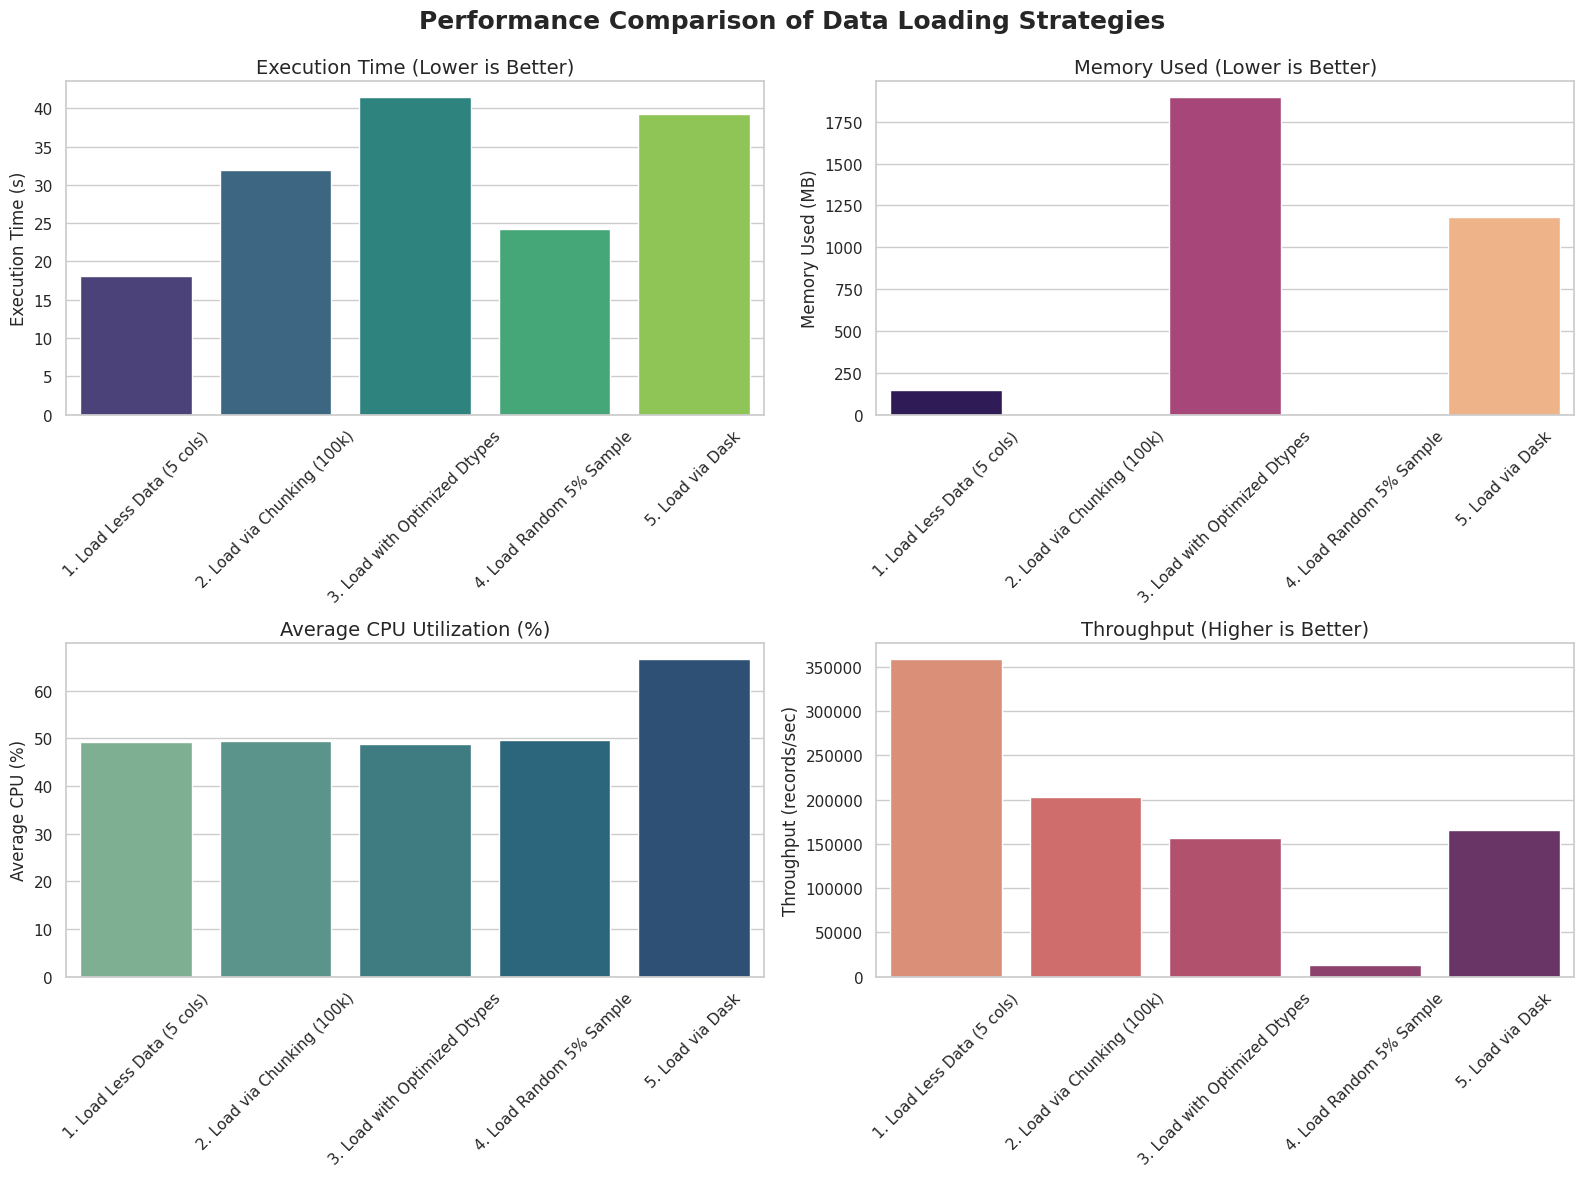

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert our results list into a DataFrame
final_df = pd.DataFrame(all_results)

# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Comparison of Data Loading Strategies', fontsize=18, fontweight='bold')

# --- Plot 1: Execution Time ---
sns.barplot(data=final_df, x='Description', y='Execution Time (s)', ax=axes[0, 0], hue='Description', palette='viridis', legend=False)
axes[0, 0].set_title('Execution Time (Lower is Better)', fontsize=14)
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Plot 2: Memory Used ---
sns.barplot(data=final_df, x='Description', y='Memory Used (MB)', ax=axes[0, 1], hue='Description', palette='magma', legend=False)
axes[0, 1].set_title('Memory Used (Lower is Better)', fontsize=14)
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Plot 3: Average CPU ---
sns.barplot(data=final_df, x='Description', y='Average CPU (%)', ax=axes[1, 0], hue='Description', palette='crest', legend=False)
axes[1, 0].set_title('Average CPU Utilization (%)', fontsize=14)
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Plot 4: Throughput ---
sns.barplot(data=final_df, x='Description', y='Throughput (records/sec)', ax=axes[1, 1], hue='Description', palette='flare', legend=False)
axes[1, 1].set_title('Throughput (Higher is Better)', fontsize=14)
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

# Clean up the layout so labels don't overlap
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Give the main title some breathing room
plt.show()

##**Library 1: Full Load With Pandas**

##**Library 1: Full Load With Dask**

##**Library 1: Full Load With Polar**

## **4. Compare Performance**



File size: 1303.99 MB. Starting benchmark...



,Time (s),Memory (MB),Avg CPU (%),Throughput (MB/s)
Pandas,42.11,1291.78,47.40,30.97
Dask,42.38,1456.53,65.25,30.77
Polars,10.02,3114.12,79.70,130.14


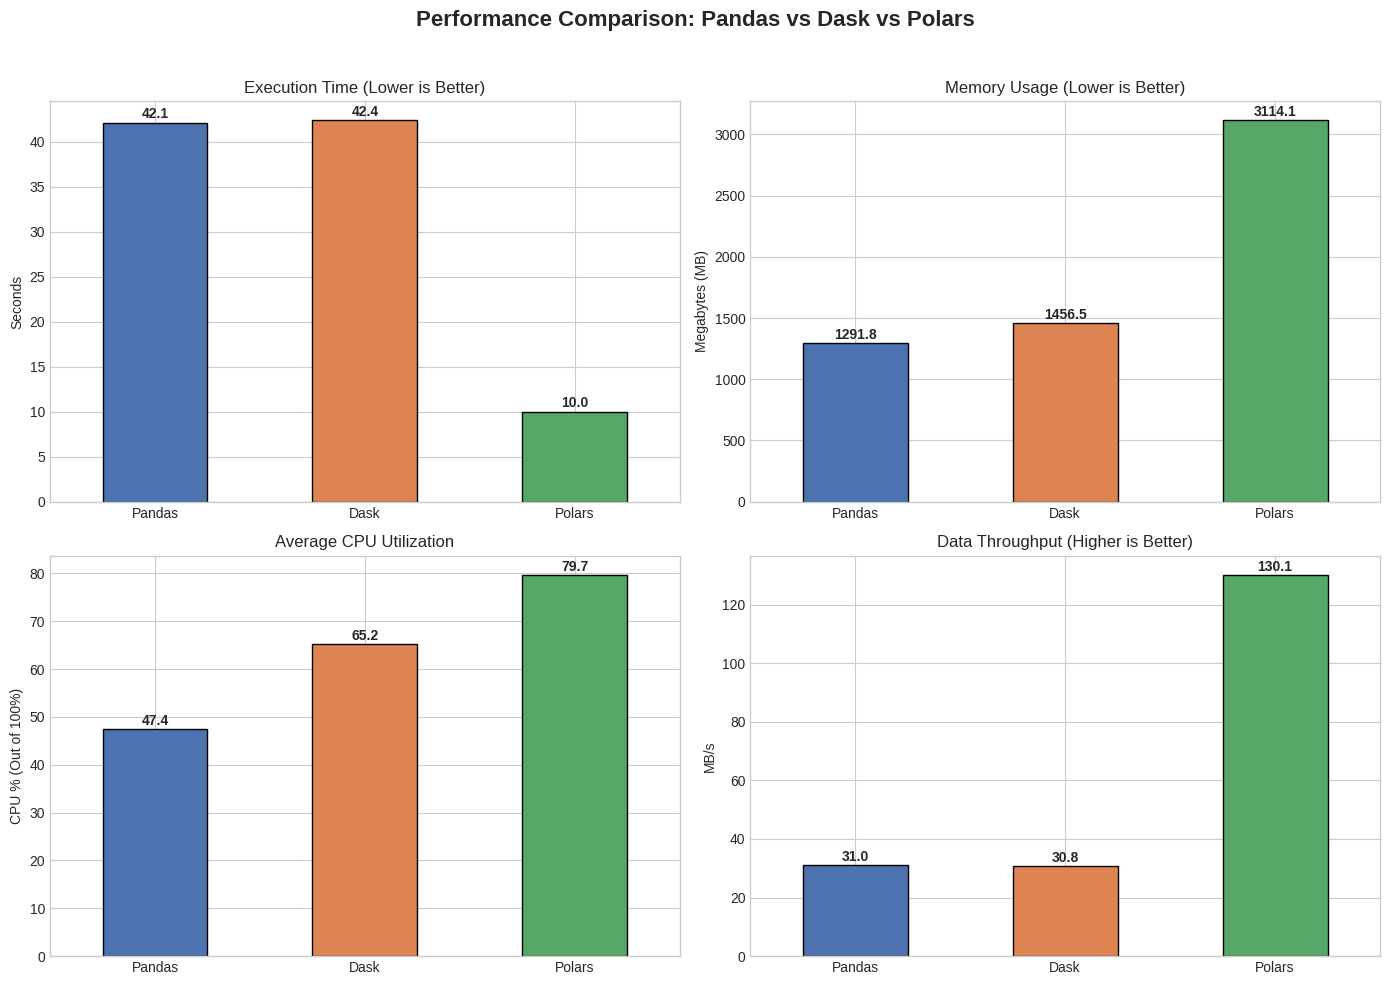

In [17]:
import time
import psutil
import os
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd
import polars as pl

# Define the file path (ensure this matches your actual file variable)
file_path = 'full_data_flightdelay.csv'

# Calculate total file size in MB for throughput calculations
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

def get_memory():
    return psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Initialize process tracking to measure CPU
process = psutil.Process(os.getpid())
num_cores = psutil.cpu_count()

results = {}

print(f"File size: {file_size_mb:.2f} MB. Starting benchmark...\n")

# 1. Pandas Performance
process.cpu_percent(interval=None) # Reset CPU counter
start_time = time.time()
mem_before = get_memory()

df_pd = pd.read_csv(file_path)

mem_after = get_memory()
time_taken = time.time() - start_time
avg_cpu = process.cpu_percent(interval=None) / num_cores # Get avg CPU relative to total system cores

results['Pandas'] = {
    'Time (s)': time_taken,
    'Memory (MB)': mem_after - mem_before,
    'Avg CPU (%)': avg_cpu,
    'Throughput (MB/s)': file_size_mb / time_taken
}
del df_pd # Free memory


# 2. Dask Performance
process.cpu_percent(interval=None) # Reset CPU counter
start_time = time.time()
mem_before = get_memory()

# Compute forces Dask to actually load the data into memory for a fair comparison
df_dd = dd.read_csv(file_path, dtype={'DEP_DEL15': 'float64', 'AWND': 'float64', 'PRCP': 'float64'}).compute()

mem_after = get_memory()
time_taken = time.time() - start_time
avg_cpu = process.cpu_percent(interval=None) / num_cores

results['Dask'] = {
    'Time (s)': time_taken,
    'Memory (MB)': mem_after - mem_before,
    'Avg CPU (%)': avg_cpu,
    'Throughput (MB/s)': file_size_mb / time_taken
}
del df_dd


# 3. Polars Performance
process.cpu_percent(interval=None) # Reset CPU counter
start_time = time.time()
mem_before = get_memory()

df_pl = pl.read_csv(file_path, ignore_errors=True)

mem_after = get_memory()
time_taken = time.time() - start_time
avg_cpu = process.cpu_percent(interval=None) / num_cores

results['Polars'] = {
    'Time (s)': time_taken,
    'Memory (MB)': mem_after - mem_before,
    'Avg CPU (%)': avg_cpu,
    'Throughput (MB/s)': file_size_mb / time_taken
}
del df_pl


# --- Create Comparison DataFrame ---
comparison_df = pd.DataFrame(results).T
display(comparison_df.round(2))

# --- Plotting the Results in a 2x2 Grid ---
# Set a cleaner style for the plots
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#4C72B0', '#DD8452', '#55A868'] # Professional color palette

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Performance Comparison: Pandas vs Dask vs Polars', fontsize=16, fontweight='bold')

# 1. Execution Time (Top Left)
comparison_df['Time (s)'].plot(kind='bar', color=colors, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Execution Time (Lower is Better)', fontsize=12)
axes[0, 0].set_ylabel('Seconds')

# 2. Memory Usage (Top Right)
comparison_df['Memory (MB)'].plot(kind='bar', color=colors, ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_title('Memory Usage (Lower is Better)', fontsize=12)
axes[0, 1].set_ylabel('Megabytes (MB)')

# 3. Avg CPU Usage (Bottom Left)
comparison_df['Avg CPU (%)'].plot(kind='bar', color=colors, ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('Average CPU Utilization', fontsize=12)
axes[1, 0].set_ylabel('CPU % (Out of 100%)')

# 4. Throughput (Bottom Right)
comparison_df['Throughput (MB/s)'].plot(kind='bar', color=colors, ax=axes[1, 1], edgecolor='black')
axes[1, 1].set_title('Data Throughput (Higher is Better)', fontsize=12)
axes[1, 1].set_ylabel('MB/s')

# Add exact value labels on top of the bars for all subplots
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0) # Keep X-axis labels horizontal
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 6), textcoords='offset points',
                    fontsize=10, fontweight='bold')

# Adjust layout so everything fits perfectly
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 📝 Task 5: Conclusion & Reflection

### Key Observations
* **Pandas** loaded the ~6.5 million flight records successfully but consumed a massive amount of RAM and took the longest execution time.
* **Dask** prevented memory crashing by splitting the airline data into partitions. However, because we forced it to compute into a single dataframe for comparison, the overhead of task scheduling made its execution time relatively long.
* **Polars** handled the massive dataset with ease. By leveraging multithreading in Rust, it significantly outperformed Pandas and Dask in execution speed.

### Benefits and Limitations
| Method | Benefits | Limitations |
| :--- | :--- | :--- |
| **Pandas** | Very intuitive, huge community support, integrates well with Scikit-Learn. | Single-threaded. Struggles with datasets approaching RAM limits. |
| **Dask** | Out-of-core computation prevents "Out of Memory" errors. Familiar Pandas-like API. | Overhead from scheduling can make it slower on single machines than pure memory tools. |
| **Polars** | Blazing fast, utilizes all CPU cores, memory efficient due to Apache Arrow framework. | Syntax (Expressions API) is very different from Pandas, steeper learning curve. |

### Reflection
Working with the 2019 Airline Delays dataset taught us that big data requires intentional memory management. A simple `pd.read_csv()` easily consumes gigabytes of RAM. By explicitly defining data types (like converting `CARRIER_NAME` to categorical data), we can shrink memory footprints dramatically. Furthermore, utilizing modern tools like Polars showed us that we can process multimillion-row datasets locally on standard hardware efficiently without needing expensive cluster setups.